# Notebook to investigate House Prices Tutorial Competition

In this notebook, I look into the tutorial competition for predicting house prices

## Code from Kaggle

The cell below was automatically generated when I created a new notebook. Let's ignore it for now

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
input_dir = '../input/'  # Use './' for submission
for dirname, _, filenames in os.walk(input_dir):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a
# version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

../input/house-prices-advanced-regression-techniques/test.csv
../input/house-prices-advanced-regression-techniques/data_description.txt
../input/house-prices-advanced-regression-techniques/train.csv
../input/house-prices-advanced-regression-techniques/sample_submission.csv


## Exploratory Data Analysis (EPA)

Let's dedicate some time to understand the data first.

In [2]:
full_training = pd.read_csv(input_dir + 'house-prices-advanced-regression-techniques/train.csv')
num_entries = full_training.shape[0]

print(f'Total number of entries in traning data = {num_entries}')

full_training.head(5)

Total number of entries in traning data = 1460


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


We can immediately see there are a lot of features here, some categorical (such as the `'MSZoning'`), and some continuous (such as the `'LotArea'`).

Recall the target variable is the sale price.

In [3]:
target_name = 'SalePrice'

### Simple plots

Let's plot a few variables 

In [4]:
import matplotlib.pyplot as plt

We will first do a naive one: plot the target variable as a function of the lot area/size, and color it based on the zone class.

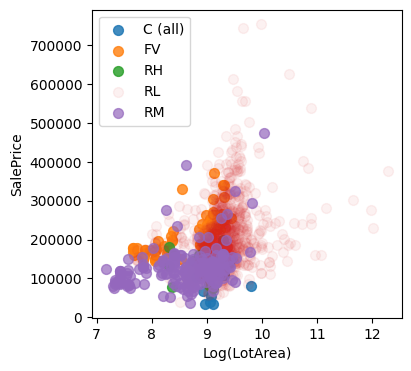

In [5]:
# Specify variables
continuous_var = 'LotArea'
categorical_var = 'MSZoning'

# Plot
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_ylabel(target_name)
ax.set_xlabel(f'Log({continuous_var})')

for zone, data in full_training.groupby(categorical_var):
    sc = ax.scatter(np.log(data[continuous_var]), data[target_name],
                    # color=colors[zone],
                    marker='o',
                    alpha=(0.85 - len(data)/num_entries),  # The more entries the lighter for visualization purposes
                    s=50,
                    label=zone)
    # sc.set_facecolor("none")

_ = ax.legend()

The distribution of the target price appears to be not normal. Let's take a quick look.

In [36]:
from typing import Dict, Tuple

from matplotlib.figure import Figure
from matplotlib.axes import Axes

def view_stats(data: pd.DataFrame,
               col_name: str,
               scale: float = 1.0,
               bins: int = 30,
               figsize: Tuple[int, int] = (5, 3)) -> Tuple[Dict, Figure, Axes]:
    """
    Auxiliary function to plot and compute helpful statistics of a certain column in the dataframe

    Args:
        data: dataframe to be used
        col_name: which column to compute statistics from
        scale: scale value to apply before computing statistics; defaults to 1.
        bins: number of bins to be used in histogram plot; defaults to 30
        figsize: size of the figure; defaults to (5, 3)

    Returns:
        a dictionary containining statistics, the figure and axes object with a histrogram of the values
    """
    # Compute stats
    median = (scale * data[col_name]).median()
    mean = (scale * data[col_name]).mean()
    std = (scale * data[col_name]).std()
    skew = (scale * data[col_name]).skew()
    kurtosis = (scale * data[col_name]).kurtosis()

    # Store in dict
    stats = {'median': median,
             'mean': mean,
             'std': std,
             'skew': skew,
             'kurtosis': kurtosis,
             'pre_scale': scale}

    # Plot
    fig, axes = plt.subplots(figsize=figsize)
    data[col_name].hist(bins=bins, ax=axes)

    # Print info
    for key, val in stats.items():
        print(f'{key.upper()}: {val}')

    return stats, fig, axes

MEDIAN: 120.5
MEAN: 126.31683027522935
STD: 48.52168983254895
SKEW: 3.2639779947070338
KURTOSIS: 17.426504302416962
PRE_SCALE: 0.001


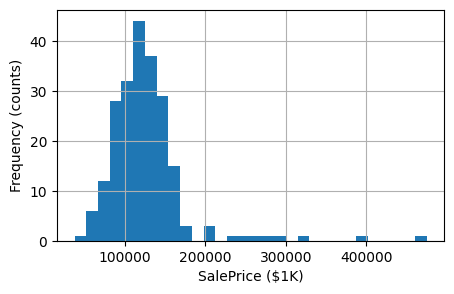

In [37]:
target_stats, fig, axes = view_stats(data=data, col_name=target_name, scale=1.0e-03)
axes.set_xlabel(f'{target_name} ($1K)')
_ = axes.set_ylabel('Frequency (counts)')

This seems to be heavily skewed data. This is likely due to the outliers past the $400K mark. Let's see if a log transformation of the data makes it a bit more Gaussian.

In [42]:
log_target_name = f"log_{target_name}"

data.loc[:, log_target_name] = np.log(data[target_name] / 1000)

MEDIAN: 4.791649752930709
MEAN: 4.785137330101994
STD: 0.31560537916783804
SKEW: 0.5096984276666682
KURTOSIS: 3.3156511713446317
PRE_SCALE: 1.0


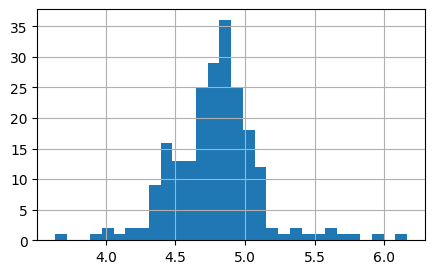

In [43]:
log_target_stats, _, _ = view_stats(data=data, col_name=log_target_name)